In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import netCDF4 as nc


In [2]:
fname = f'/srv/scratch/z3533156/26year_BRAN2020/outer_avg_01461.nc'
dataset = nc.Dataset(fname)
lon_rho = np.transpose(dataset.variables['lon_rho'], axes=(1, 0))
lat_rho = np.transpose(dataset.variables['lat_rho'], axes=(1, 0))
mask_rho = np.transpose(dataset.variables['mask_rho'], axes=(1, 0))
h = np.transpose(dataset.variables['h'], axes=(1, 0))
# f = np.transpose(dataset.variables['f'], axes=(1, 0))
angle = dataset.variables['angle'][0, 0]
z_r = np.load('/srv/scratch/z5297792/z_r.npy')
z_r = np.transpose(z_r, (1, 2, 0))
def distance(lat1, lon1, lat2, lon2):
    EARTH_RADIUS = 6357
    lat1, lon1, lat2, lon2 = map(np.radians, [lat1, lon1, lat2, lon2])
    dlat, dlon = lat2 - lat1, lon2 - lon1
    a = np.sin(dlat/2)**2 + np.cos(lat1)*np.cos(lat2)*np.sin(dlon/2)**2
    return EARTH_RADIUS * 2 * np.arctan2(np.sqrt(a), np.sqrt(1 - a))
j_mid, i_mid = lon_rho.shape[1] // 2, lon_rho.shape[0] // 2
dx = distance(lat_rho[:-1, j_mid], lon_rho[:-1, j_mid],
              lat_rho[1:, j_mid], lon_rho[1:, j_mid])
dy = distance(lat_rho[i_mid, :-1], lon_rho[i_mid, :-1],
              lat_rho[i_mid, 1:], lon_rho[i_mid, 1:])
x_grid = np.insert(np.cumsum(dx), 0, 0)
y_grid = np.insert(np.cumsum(dy), 0, 0)
X_grid, Y_grid = np.meshgrid(x_grid, y_grid, indexing='ij')


In [3]:
df_ameda = pd.read_pickle('/srv/scratch/z5297792/SEACOFS_26yr_eddy_dataset/AMEDA/df_ameda_renamed.pkl')
df_ameda


,Eddy,Day,Cyc,lon,lat,ic,jc,xc,yc,w,...,large1,split,split2,merge,merge2,shapes2,interaction,interaction2,area,deta
0,1,1462,AE,159.538447,-33.372496,256,186,895.838095,919.548973,0.00001,...,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,46653.514371,-0.000011
1,1,1463,AE,159.686966,-33.160751,257,192,903.002279,946.853133,0.000019,...,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,4313.383226,-0.000164
2,1,1464,AE,159.649836,-33.118402,256,192,898.424872,950.150915,0.000019,...,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,4336.799061,-0.00007
3,1,1465,AE,159.686966,-33.118402,257,193,901.765461,951.353349,0.000019,...,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,6480.379311,-0.000047
4,1,1466,AE,159.575577,-32.949006,254,196,886.770848,965.738198,0.00002,...,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,6101.676103,-0.000401
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
104565,3519,10643,CE,154.897235,-28.841152,125,252,327.112431,1244.142958,-0.000014,...,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1147.953129,0.000186
104566,3519,10647,CE,154.860106,-29.052897,127,247,331.141370,1220.843200,-0.000011,...,1.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,8038.013328,0.000109
104567,3519,10648,CE,154.897235,-29.222293,130,244,340.502393,1204.416117,-0.000011,...,1.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,9866.414298,0.000095
104568,3519,10649,CE,154.37742,-28.417662,100,257,264.105244,1270.945276,-0.00001,...,1.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,5581.424065,0.000003


In [4]:
eddy_props = []
for eddy in df_ameda.Eddy.unique():
    df = df_ameda[df_ameda.Eddy==eddy].copy()
    eddy_props.extend(np.array(np.hypot(df.xc.diff(), df.yc.diff()) * 0.011574))
df_ameda['EddyProp'] = eddy_props


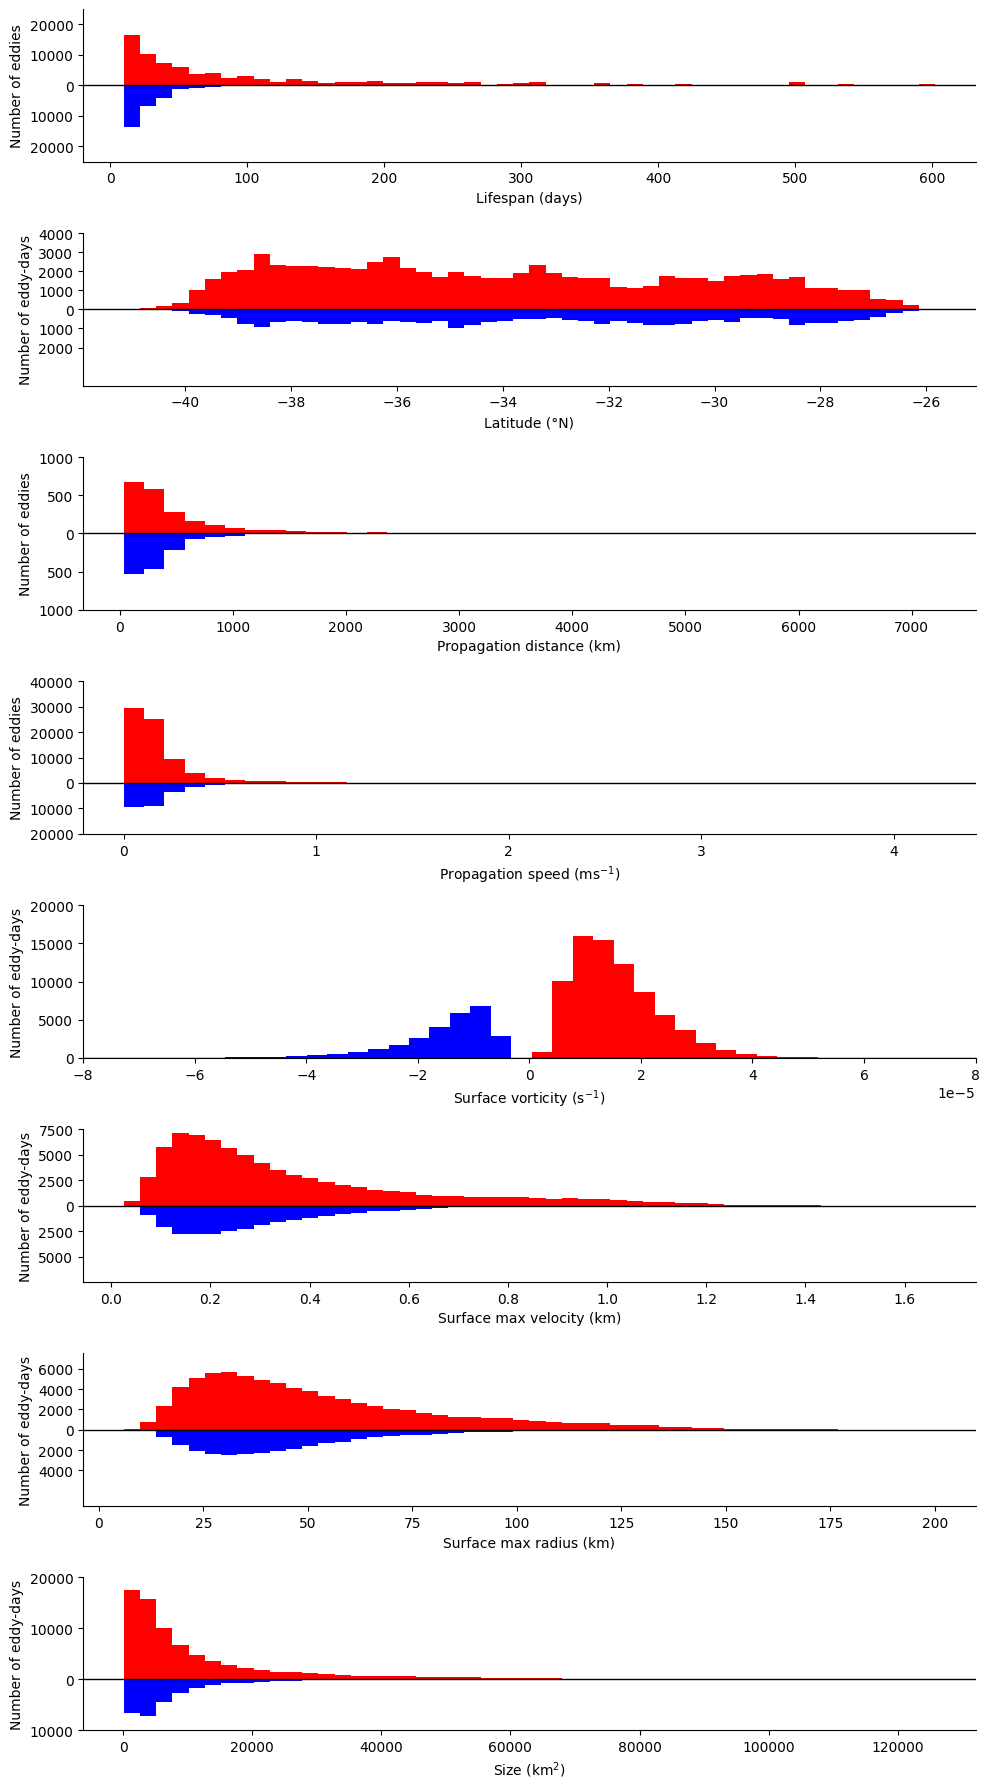

In [5]:
fig, axs = plt.subplots(8, 1, figsize=(10, 18))

def clean(a, b):
    a = np.asarray(a, dtype=float)
    b = np.asarray(b, dtype=float)
    return a[np.isfinite(a)], b[np.isfinite(b)]

def shared_bins(a, b, method='fd', min_bins=12, max_bins=40):
    a, b = clean(a, b)
    all_vals = np.concatenate([a, b])
    
    if all_vals.size == 0:
        return np.linspace(0, 1, min_bins + 1)
    if np.all(all_vals == all_vals[0]):
        return np.linspace(all_vals[0] - 0.5, all_vals[0] + 0.5, min_bins + 1)

    edges = np.histogram_bin_edges(all_vals, bins=method)
    n_bins = len(edges) - 1

    if n_bins < min_bins:
        edges = np.linspace(all_vals.min(), all_vals.max(), min_bins + 1)
    elif n_bins > max_bins:
        edges = np.linspace(all_vals.min(), all_vals.max(), max_bins + 1)

    return edges

def mirrored_hist(ax, ae, ce, bins, xlabel, ylabel, ylim=None, xlim=None, mirror_flag=True):
    ae, ce = clean(ae, ce)

    ax.hist(ae, bins=bins, color='r')
    counts, edges = np.histogram(ce, bins=bins)
    if mirror_flag:
        ax.bar(edges[:-1], -counts, width=np.diff(edges), color='b', align='edge')
    else:
        ax.bar(edges[:-1], counts, width=np.diff(edges), color='b', align='edge')

    ax.axhline(0, color='k', linewidth=1)
    ax.set_xlabel(xlabel)
    ax.set_ylabel(ylabel)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.set_yticks(ax.get_yticks())
    ax.set_yticklabels([abs(int(t)) for t in ax.get_yticks()])

    if ylim is not None:
        ax.set_ylim(ylim)
    if xlim is not None:
        ax.set_xlim(xlim)

# --- Plot 0: Age ---
ae = df_ameda.loc[df_ameda.Cyc == 'AE', 'Age']
ce = df_ameda.loc[df_ameda.Cyc == 'CE', 'Age']
bins0 = shared_bins(ae, ce, method='fd', min_bins=20, max_bins=50)
mirrored_hist(
    axs[0], ae, ce, bins0,
    'Lifespan (days)', 'Number of eddies',
    ylim=(-25000, 25000)
)

# --- Plot 1: Lat ---
ae = df_ameda.loc[df_ameda.Cyc == 'AE', 'lat']
ce = df_ameda.loc[df_ameda.Cyc == 'CE', 'lat']
bins1 = shared_bins(ae, ce, method='fd', min_bins=20, max_bins=50)
mirrored_hist(
    axs[1], ae, ce, bins1,
    'Latitude (°N)', 'Number of eddy-days',
    ylim=(-4000, 4000)
)

# --- Plot 2: Propagation Distance ---
eddy_props_AE, eddy_props_CE = [], []
for eddy in df_ameda.Eddy.unique():
    df = df_ameda[df_ameda.Eddy == eddy]
    dist = np.nansum(np.hypot(df.xc.diff(), df.yc.diff()))
    if df.iloc[0].Cyc == 'AE':
        eddy_props_AE.append(dist)
    else:
        eddy_props_CE.append(dist)

bins2 = shared_bins(eddy_props_AE, eddy_props_CE, method='fd', min_bins=15, max_bins=40)
mirrored_hist(
    axs[2], eddy_props_AE, eddy_props_CE, bins2,
    'Propagation distance (km)', 'Number of eddies',
    # ylim=(-450, 450)
)

# --- Plot 3: Propagation Speed ---
dfAE = df_ameda[df_ameda.Cyc == 'AE'].copy()
# dfAE = dfAE[dfAE.EddyProp <= 1]
dfCE = df_ameda[df_ameda.Cyc == 'CE'].copy()
# dfCE = dfCE[dfCE.EddyProp <= 1]

bins3 = shared_bins(dfAE.EddyProp, dfCE.EddyProp, method='fd', min_bins=15, max_bins=40)
mirrored_hist(
    axs[3], dfAE.EddyProp, dfCE.EddyProp, bins3,
    r'Propagation speed (ms$^{-1}$)', 'Number of eddies',
    # ylim=(-13000, 13000)
)

# --- Plot 4: Vorticity ---
df_v = df_ameda.copy()#[df_ameda.OW.abs() <= 8e-5]
ae = df_v.loc[df_v.Cyc == 'AE', 'w']
ce = df_v.loc[df_v.Cyc == 'CE', 'w']
bins4 = shared_bins(ae, ce, method='fd', min_bins=20, max_bins=50)
mirrored_hist(
    axs[4], ae, ce, bins4,
    r'Surface vorticity (s$^{-1}$)', 'Number of eddy-days',
    xlim=(-8e-5, 8e-5),
    mirror_flag=False
)

# --- Plot 6: Depth ---
ae = df_ameda.loc[df_ameda.Cyc == 'AE', 'velmax']
ce = df_ameda.loc[df_ameda.Cyc == 'CE', 'velmax']
bins5 = shared_bins(ae, ce, method='fd', min_bins=20, max_bins=50)
mirrored_hist(
    axs[5], ae, ce, bins5,
    r'Surface max velocity (km)', 'Number of eddy-days',
    ylim=(-7500, 7500)
)

# --- Plot 5: Radius ---
ae = df_ameda.loc[df_ameda.Cyc == 'AE', 'rmax']
ce = df_ameda.loc[df_ameda.Cyc == 'CE', 'rmax']
bins5 = shared_bins(ae, ce, method='fd', min_bins=20, max_bins=50)
mirrored_hist(
    axs[6], ae, ce, bins5,
    r'Surface max radius (km)', 'Number of eddy-days',
    ylim=(-7500, 7500)
)

# --- Plot 7: Aspect ratio ---
ae = df_ameda.loc[df_ameda.Cyc == 'AE', 'area']
ce = df_ameda.loc[df_ameda.Cyc == 'CE', 'area']
bins5 = shared_bins(ae, ce, method='fd', min_bins=20, max_bins=50)
mirrored_hist(
    axs[7], ae, ce, bins5,
    r'Size (km$^{2}$)', 'Number of eddy-days',
    # ylim=(-7500, 7500)
)

plt.tight_layout()
plt.show()
